# **Projeto Análise Exploratória e Estatística de Dados**
## Importando as bibliotecas e o DataFrame

In [222]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações globais
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', None)
#plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.family'] = 'Arial'
sns.set_theme(style='white')
#sns.set_palette(['#005CA9','#F39200'])
# Formata as variáveis do tipo float com duas casas decimais
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
COR_PRINCIPAL = '#005CA9'
COR_DESTAQUE = '#F39200'

In [223]:
# Carregando o arquivo csv
csv_file = r'..\data\raw\vendas_supermercado_com_cliente.csv'
df = pd.read_csv(csv_file)

In [ ]:
# Funções
def formata_br(valor):
    return (
        f'R$ {valor:,.2f}'
        .replace(',','X')
        .replace('.',',')
        .replace('X','.')
    )
def formata_br_inteiro(valor):
    return f'R$ {valor:,.0f}'.replace(',','.')

## Limpeza e tratamento dos dados
### 1. Visualização do dataframe

In [225]:
# Verificando as dimensões do DataFrame (linhas e colunas)
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Linhas: 20075
Colunas: 9


In [226]:
# Verificando as primeiras linhas do DataFrame
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,"2,715.61"
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.56,29,"2,280.15"
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.90,67,"4,419.56"
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.45,29,"3,809.17"
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.96,24,"1,013.42"


In [227]:
# Verificando as últimas linhas do DataFrame
df.tail()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
20070,2023-12-31,Produtos de higiene para pets,Pet Shop,26.62,15,0.21,315.45,39,"2,475.82"
20071,2023-12-31,Panelas,Utilidades Domésticas,33.00,19,0.15,532.95,25,"4,766.49"
20072,2023-12-31,Talheres,Utilidades Domésticas,27.60,12,0.29,235.15,65,"3,367.68"
20073,2023-12-31,Copos,Utilidades Domésticas,15.35,13,0.25,149.66,42,"3,823.50"
20074,2023-12-31,"Produtos descartáveis (pratos, copos, talheres)",Utilidades Domésticas,32.06,6,0.11,171.20,59,"3,303.47"


In [228]:
# Verificando cinco linhas aleatórias do DataFrame
df.sample(5)

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
4905,2023-03-31,Tilápia,Alimentos Frescos,5.62,17,0.00,95.54,43,"3,906.58"
12431,2023-08-15,Bananas,Alimentos Frescos,43.85,18,0.10,710.37,69,"2,106.91"
13440,2023-09-02,Farinha,Produtos de Mercearia,43.55,13,0.00,566.15,27,"2,936.71"
17166,2023-11-09,Frango,Alimentos Frescos,11.02,17,0.00,187.34,27,"4,390.20"
17082,2023-11-07,Sabão em pó,Produtos de Limpeza,45.97,8,0.00,367.76,47,"2,949.30"


In [229]:
df.columns

Index(['Data', 'Produto', 'Categoria', 'Preço', 'Quantidade', 'Desconto',
       'Total_Venda', 'Idade', 'Renda'],
      dtype='str')

In [279]:
# Resumo do DataFrame
resumo = pd.DataFrame({
    'feature': df.columns,
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(dropna=True),
    'missing': df.isna().sum(),
    'missing_%': df.isna().sum().mul(100).round(2)
}).reset_index(drop=True)
resumo

,feature,dtype,n_unicos,missing,missing_%
0,Data,datetime64[us],365,0,0
1,Produto,str,55,0,0
2,Categoria,str,9,0,0
3,Preço,float64,4811,0,0
4,Quantidade,int64,19,0,0
5,Desconto,float64,47,0,0
6,Total_Venda,float64,16510,0,0
7,Idade,int64,57,0,0
8,Renda,float64,19581,0,0
9,Faixa_Etaria,category,3,0,0


### 2. Diagnóstico de qualidade

In [231]:
# Verificando os tipos de dados e contagem de nulos por colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  str    
 1   Produto      20075 non-null  str    
 2   Categoria    20075 non-null  str    
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 1.4 MB


### 3. Consistência

In [232]:
# Verificando a quantidade de valores distintos por variável
print(df.nunique())

Data             365
Produto           55
Categoria          9
Preço           4811
Quantidade        19
Desconto          47
Total_Venda    16510
Idade             57
Renda          19581
dtype: int64


In [233]:
# Verificando a consistência dos itens das colunas
for col in df.columns:
    if df[col].nunique():
        print(col)
        print(df[col].unique())
        print('-'*100)

Data
<StringArray>
['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
 '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10',
 ...
 '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26',
 '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2023-12-31']
Length: 365, dtype: str
----------------------------------------------------------------------------------------------------
Produto
<StringArray>
[                                          'Maçãs',
                                         'Bananas',
                                        'Laranjas',
                                         'Tomates',
                                          'Alface',
                                        'Cenouras',
                                          'Frango',
                                    'Carne bovina',
                                     'Carne suína',
                                          'Salmão',
                         

### 4. Duplicados

In [234]:
# Contagem de linhas totalmente duplicadas
n_duplicadas = df.duplicated().sum()
print(f'Linhas totalmente duplicadas: {n_duplicadas}')

if n_duplicadas == 0:
    print('Nenhuma linha totalmente duplicada para ser removida.')
else:
    df = df.drop_duplicates(keep='first')
    print(f'Linhas duplicadas removidas: {n_duplicadas}')

Linhas totalmente duplicadas: 0
Nenhuma linha totalmente duplicada para ser removida.


In [282]:
# Verificando se há observações com informações duplicadas nas colunas 'Data','Produto','Quantidade','Total_Venda' simultâneamente
display(df.loc[df.duplicated(subset=['Data','Produto','Quantidade','Total_Venda'])].head())

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Faixa_Etaria,Mes,Dia_Semana,Com_Desconto


Nenhuma observações com informações duplicadas nas colunas 'Data','Produto','Quantidade','Total_Venda' simultâneamente.</br></br>

In [285]:
# Verificando quantidade de Informações para analisar duplicidade de observações nas colunas `Produto`, `Quantidade`, `Total_Venda`
df.duplicated(subset=['Produto','Quantidade','Total_Venda']).sum()

np.int64(19)

In [286]:
# Observações que possuem as mesmas informações nas colunas `Produto`, `Quantidade`, `Total_Venda`
display(df.loc[df.duplicated(subset=['Produto','Quantidade','Total_Venda'])])

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Faixa_Etaria,Mes,Dia_Semana,Com_Desconto
7561,2023-05-18,Refrigerantes,Bebidas,44.09,14,0.00,617.26,55,"1,805.08",Adulto (36-59),Maio,Quinta,False
8421,2023-06-03,Frango,Alimentos Frescos,23.97,2,0.00,47.94,21,"2,486.95",Jovem (18-35),Junho,Sábado,False
9447,2023-06-21,Pizzas congeladas,Congelados,18.72,17,0.00,318.24,36,"3,798.63",Adulto (36-59),Junho,Quarta,False
10258,2023-07-06,Água mineral,Bebidas,38.55,8,0.00,308.40,55,"1,036.91",Adulto (36-59),Julho,Quinta,False
12718,2023-08-20,Pão integral,Alimentos Frescos,6.81,1,0.00,6.81,66,"4,753.34",Idoso (60+),Agosto,Domingo,False
12850,2023-08-22,Esponjas,Produtos de Limpeza,23.06,18,0.00,415.08,67,"3,942.96",Idoso (60+),Agosto,Terça,False
13747,2023-09-07,Talheres,Utilidades Domésticas,37.98,15,0.00,569.70,21,"1,701.98",Jovem (18-35),Setembro,Quinta,False
13867,2023-09-10,Carne bovina,Alimentos Frescos,12.43,5,0.00,62.15,59,"1,131.47",Adulto (36-59),Setembro,Domingo,False
14064,2023-09-13,Desodorantes,Produtos de Higiene Pessoal,38.63,19,0.00,733.97,26,"2,296.67",Jovem (18-35),Setembro,Quarta,False
14219,2023-09-16,Cervejas,Bebidas,47.04,9,0.00,423.36,52,"4,934.79",Adulto (36-59),Setembro,Sábado,False


In [237]:
df.query('Produto == "Refrigerantes" and Quantidade == 14 and Total_Venda == 617.26')

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
3051,2023-02-25,Refrigerantes,Bebidas,44.09,14,0.00,617.26,67,"1,747.71"
7561,2023-05-18,Refrigerantes,Bebidas,44.09,14,0.00,617.26,55,"1,805.08"


Analisando estas observações, constatamos que apesar de ter o mesmo Produto, Quantidade e Total_Venda, não se trata de duplicidade da observação.</br>
Vendas ocorridas em datas diferentes e por clientes diferentes.</br></br></br>

### 5. Faltantes

In [238]:
# Verificando valores nulos
df.isna().sum()

Data           0
Produto        0
Categoria      0
Preço          0
Quantidade     0
Desconto       0
Total_Venda    0
Idade          0
Renda          0
dtype: int64

## Feature Engineering
### Variável Categórica

In [239]:
# Criando variável `Faixa_Etaria`
# Jovem: 18 - 35 anos | Adulto: 36 a 59 anos | Idoso: 60 anos ou mais
idades = [0, 35, 59, 120]
labels = ['Jovem (18-35)', 'Adulto (36-59)', 'Idoso (60+)']
df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=idades, labels=labels, right=True)

### Variáveis de Data

In [240]:
# Convertendo a coluna de `Data` para o formato datetime
df['Data'] = pd.to_datetime(df['Data'])

# Mapeamento dos meses do ano
meses_map ={
    1: 'Janeiro',
    2: 'Fevereiro',
    3: 'Março',
    4: 'Abril',
    5: 'Maio',
    6: 'Junho',
    7: 'Julho',
    8: 'Agosto',
    9: 'Setembro',
    10: 'Outubro',
    11: 'Novembro',
    12: 'Dezembro'
}

# Mapeamento dos dias da semana
dias_semana_map = {
    0: 'Segunda',
    1: 'Terça',
    2: 'Quarta',
    3: 'Quinta',
    4: 'Sexta',
    5: 'Sábado',
    6: 'Domingo'
}
# Criando novas variáveis de data
df['Mes'] = df['Data'].dt.month.map(meses_map)
df['Dia_Semana'] = df['Data'].dt.dayofweek.map(dias_semana_map)

### Variável Booleana

In [241]:
# Criando variável `Com_Desconto`
# Indicador de venda em promoção
df['Com_Desconto'] = df['Desconto'] > 0

In [242]:
# Visualizando info() após tratamento dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Data          20075 non-null  datetime64[us]
 1   Produto       20075 non-null  str           
 2   Categoria     20075 non-null  str           
 3   Preço         20075 non-null  float64       
 4   Quantidade    20075 non-null  int64         
 5   Desconto      20075 non-null  float64       
 6   Total_Venda   20075 non-null  float64       
 7   Idade         20075 non-null  int64         
 8   Renda         20075 non-null  float64       
 9   Faixa_Etaria  20075 non-null  category      
 10  Mes           20075 non-null  str           
 11  Dia_Semana    20075 non-null  str           
 12  Com_Desconto  20075 non-null  bool          
dtypes: bool(1), category(1), datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 1.7 MB


In [243]:
df.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Faixa_Etaria,Mes,Dia_Semana,Com_Desconto
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,"2,715.61",Adulto (36-59),Janeiro,Domingo,False
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.56,29,"2,280.15",Jovem (18-35),Janeiro,Domingo,False
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.90,67,"4,419.56",Idoso (60+),Janeiro,Domingo,False
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.45,29,"3,809.17",Jovem (18-35),Janeiro,Domingo,False
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.96,24,"1,013.42",Jovem (18-35),Janeiro,Domingo,False


## Requisitos de Estatística Descritiva
### Medidas Estatísticas

In [244]:
# Visualizando medidas estatísticas
df.describe()

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,"20,075.00","20,075.00","20,075.00","20,075.00","20,075.00","20,075.00"
mean,2023-07-02 00:00:00,25.58,10.01,0.04,245.90,45.99,"2,999.03"
min,2023-01-01 00:00:00,1.00,1.00,0.00,0.91,18.00,"1,000.38"
25%,2023-04-02 00:00:00,13.26,5.00,0.00,75.60,32.00,"1,993.62"
50%,2023-07-02 00:00:00,25.66,10.00,0.00,186.32,46.00,"2,998.83"
75%,2023-10-01 00:00:00,37.77,15.00,0.00,370.04,60.00,"4,007.68"
max,2023-12-31 00:00:00,49.99,19.00,0.50,949.05,74.00,"4,999.76"
std,NaN,14.12,5.49,0.09,207.77,16.48,"1,159.72"


In [245]:
# Variáveis quantitativas (numéricas)
number_col = df.select_dtypes(include=[np.number]).columns.tolist()
print(number_col)

['Preço', 'Quantidade', 'Desconto', 'Total_Venda', 'Idade', 'Renda']


Medidas de têndencia central (média, mediana, moda) e de dispersão ( desvio-padrão, variância, amplitude, coeficiente de variação) para as variáveis numéricas: `Preço`, `Quantidade`, `Desconto`, `Total_Venda`, `Idade` e `Renda`.</br>
Medidas separatrizes (quartis, percentis) e identificação de outliers via bolplot e/ou regra do IRQ (1,5 * IRQ) e/ou z-score, discutindo se os outliers devem ser mantidos, tratados ou removidos.</br>
Análise da forma da distribuição (histograma, assimetria/skewness e curtose) das variáveis-chave: (ex: valor da venda , idade), indicando se aparentam seguir uma distribuição normal.

In [246]:
# Resumo estatístico para as colunas numéricas
resumo_estatistico = df.describe().T[1:]

resumo_estatistico['median'] = df[number_col].median()
resumo_estatistico['mode'] = df[number_col].mode().iloc[0]
resumo_estatistico['amp'] = resumo_estatistico['max'] - resumo_estatistico['min']
resumo_estatistico['cv'] =resumo_estatistico['std'] / resumo_estatistico['mean']
resumo_estatistico['skew'] = df[number_col].skew()
resumo_estatistico['kurtosis'] = df[number_col].kurtosis()
resumo_estatistico['iqr'] = resumo_estatistico['75%'] - resumo_estatistico['25%']

resumo_estatistico = resumo_estatistico[['count', 'mean', 'min', 'max', '25%', '50%', '75%', 'iqr', 'std', 'mode', 'amp', 'cv', 'skew', 'kurtosis']]
resumo_estatistico = resumo_estatistico \
    .rename(
    columns={
    '50%': 'median',
    '25%': 'q1',
    '75%': 'q3'})

display(resumo_estatistico)

,count,mean,min,max,q1,median,q3,iqr,std,mode,amp,cv,skew,kurtosis
Preço,"20,075.00",25.58,1.00,49.99,13.26,25.66,37.77,24.51,14.12,10.58,48.99,0.55,-0.01,-1.21
Quantidade,"20,075.00",10.01,1.00,19.00,5.00,10.00,15.00,10.00,5.49,6.00,18.00,0.55,-0.00,-1.21
Desconto,"20,075.00",0.04,0.00,0.50,0.00,0.00,0.00,0.00,0.09,0.00,0.50,2.14,2.16,4.21
Total_Venda,"20,075.00",245.90,0.91,949.05,75.60,186.32,370.04,294.44,207.77,50.04,948.14,0.84,0.99,0.25
Idade,"20,075.00",45.99,18.00,74.00,32.00,46.00,60.00,28.00,16.48,52.00,56.00,0.36,-0.01,-1.20
Renda,"20,075.00","2,999.03","1,000.38","4,999.76","1,993.62","2,998.83","4,007.68","2,014.05","1,159.72","1,630.87","3,999.38",0.39,-0.00,-1.21


### BoxPlots, Histogramas e KDEs

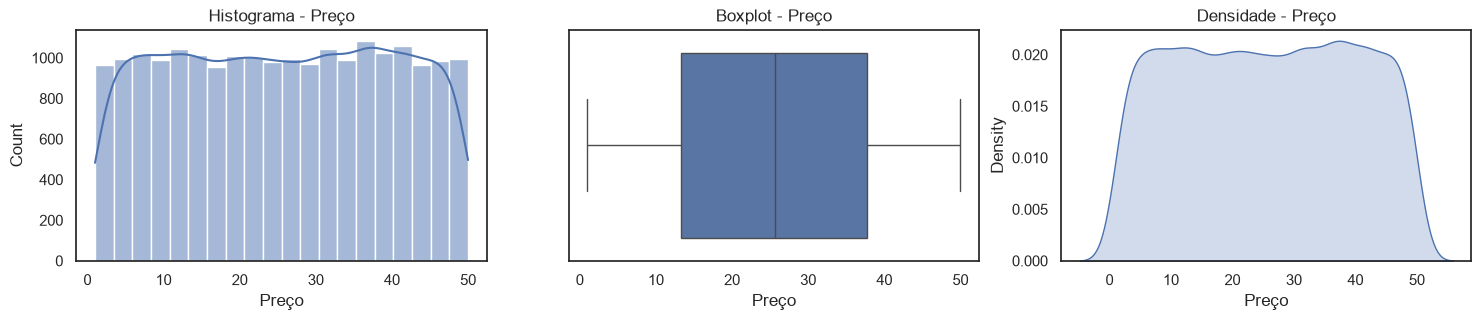

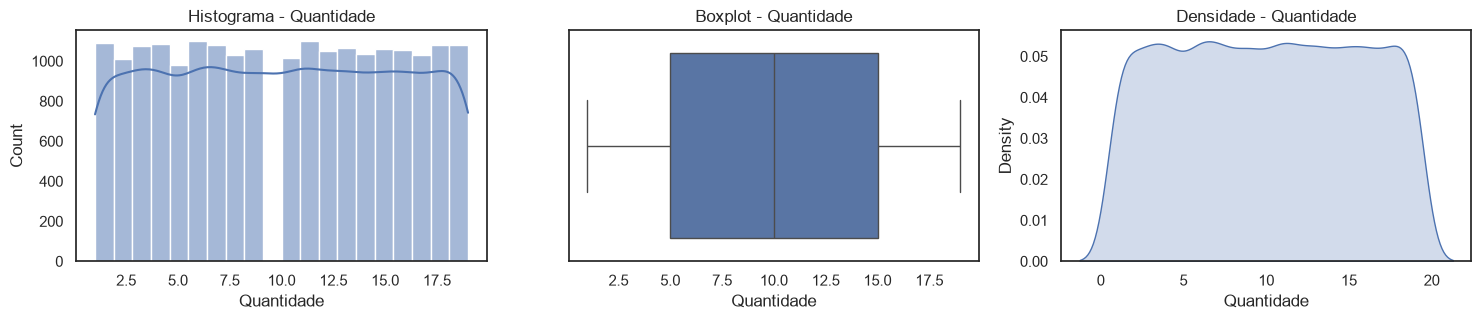

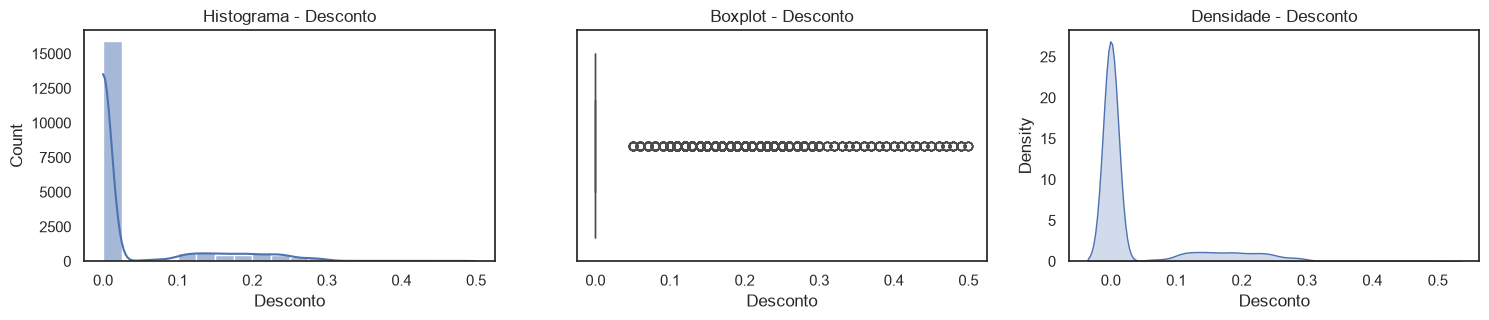

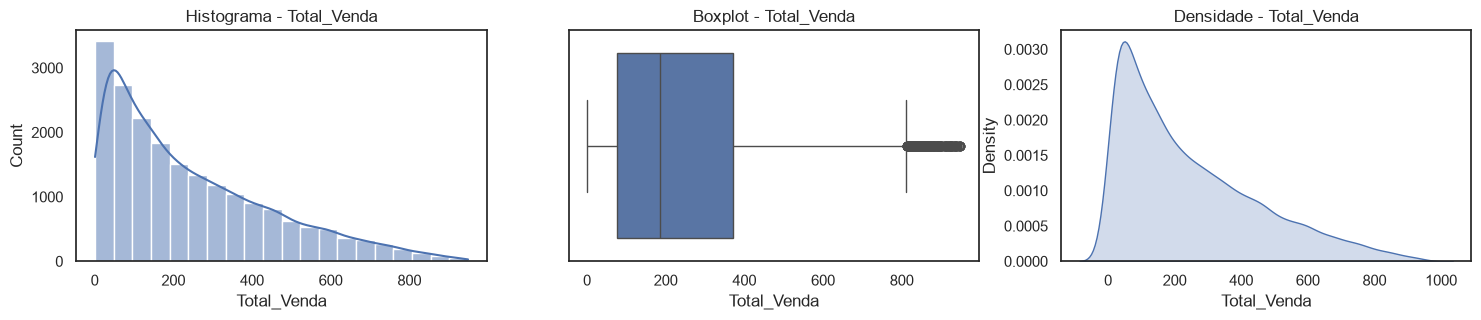

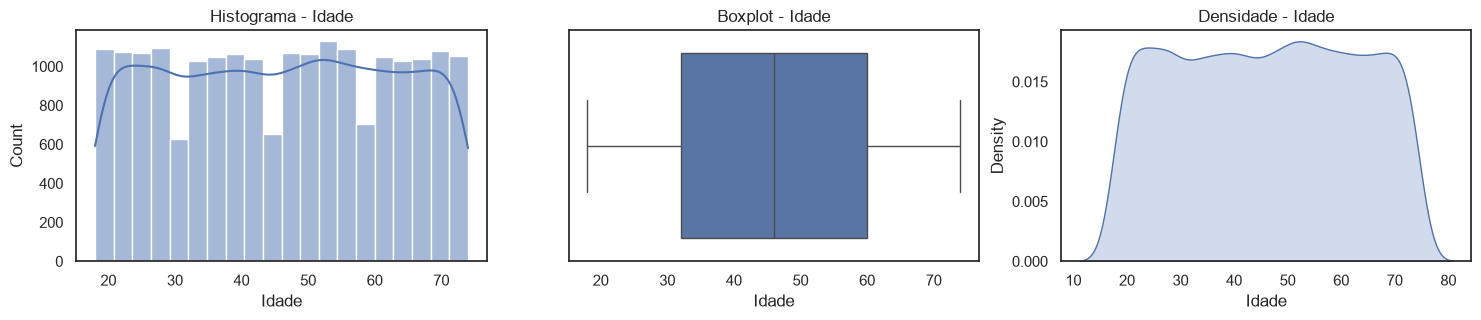

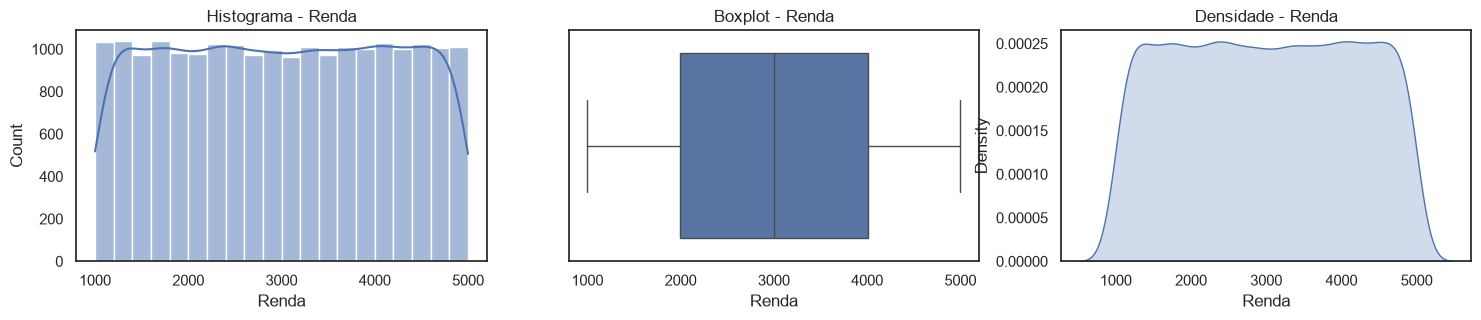

In [247]:
# Gerando os BoxPlots e Histogramas e KDE das variáveis quantitativas

for col in number_col:
    fig, ax = plt.subplots(1, 3, figsize=(18,3))
    sns.histplot(data=df, x=col, kde=True, ax=ax[0], bins=20)
    ax[0].set_title(f'Histograma - {col}')
    sns.boxplot(data=df, x=col, ax=ax[1])
    ax[1].set_title(f'Boxplot - {col}')
    sns.kdeplot(data=df, x=col, fill=True)
    ax[2].set_title(f'Densidade - {col}')
    
    plt.show()

### PairPlot

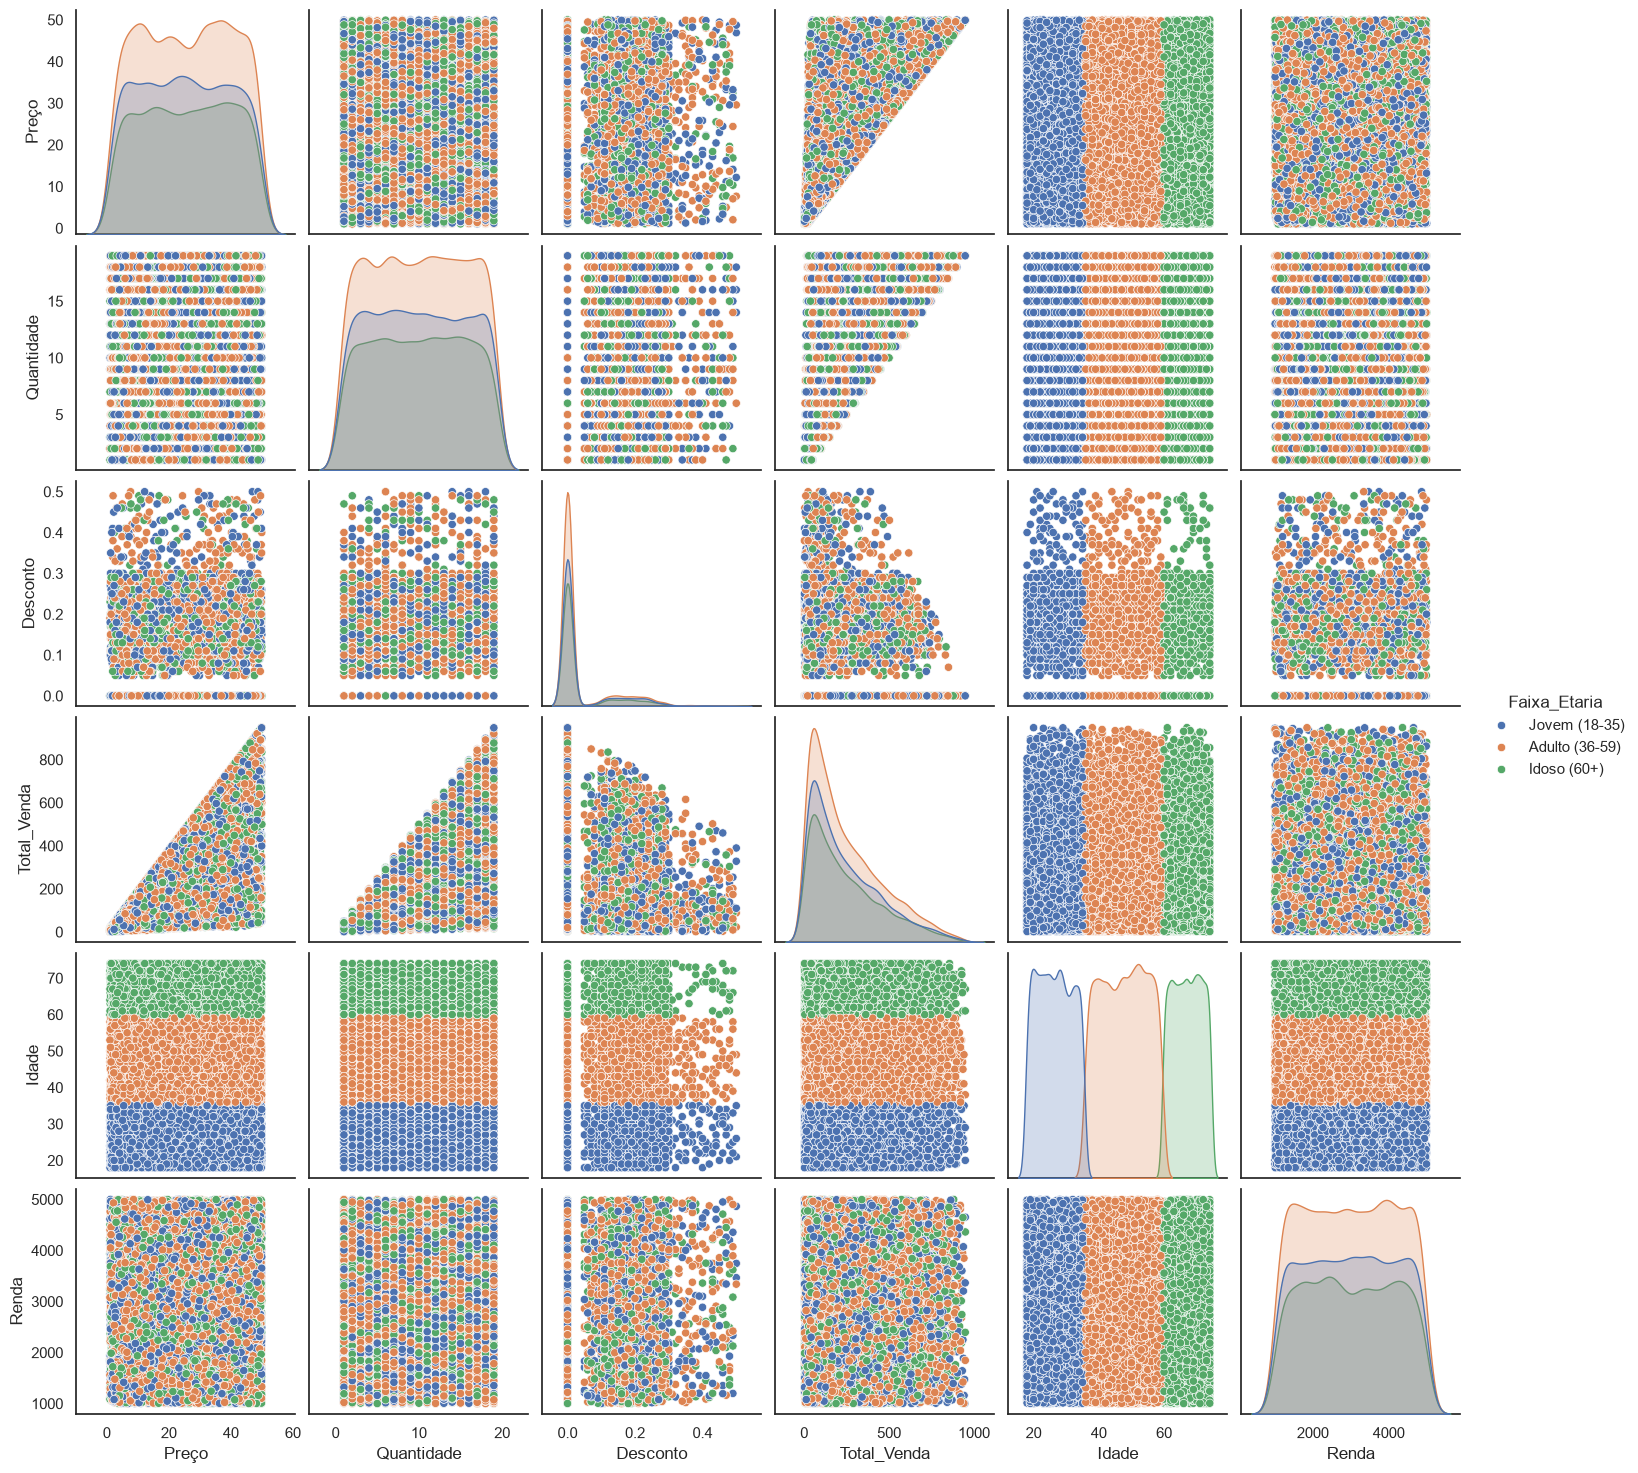

In [289]:
sns.pairplot(data=df, vars=number_col,
       hue='Faixa_Etaria')
plt.show()

### Correlação de Pearson

In [287]:
# Correlação de Pearson
df_corr_pearson = df[number_col].dropna().corr('pearson')
df_corr_pearson

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Preço,1.00,0.00,-0.00,0.66,0.01,0.01
Quantidade,0.00,1.00,-0.00,0.65,-0.01,-0.02
Desconto,-0.00,-0.00,1.00,-0.11,-0.01,-0.02
Total_Venda,0.66,0.65,-0.11,1.00,0.01,-0.01
Idade,0.01,-0.01,-0.01,0.01,1.00,-0.00
Renda,0.01,-0.02,-0.02,-0.01,-0.00,1.00


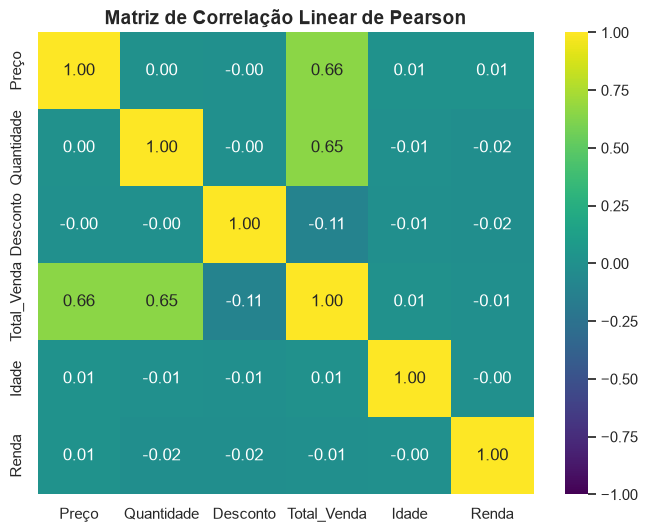

In [250]:
# Matriz de correlação e Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_pearson, annot=True, cmap='viridis', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear de Pearson', fontsize=14, fontweight='bold')
plt.show()

### Correlação de Spearman

In [251]:
df_corr_spearman = df[number_col].dropna().corr('spearman')
df_corr_spearman

,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
Preço,1.00,0.00,-0.00,0.67,0.01,0.01
Quantidade,0.00,1.00,-0.00,0.66,-0.01,-0.02
Desconto,-0.00,-0.00,1.00,-0.09,-0.02,-0.02
Total_Venda,0.67,0.66,-0.09,1.00,0.01,-0.01
Idade,0.01,-0.01,-0.02,0.01,1.00,-0.00
Renda,0.01,-0.02,-0.02,-0.01,-0.00,1.00


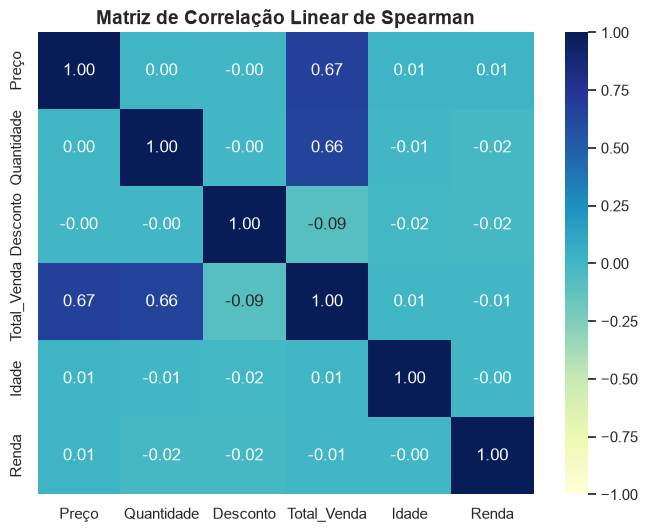

In [252]:
# Matriz de correlação e Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_spearman, annot=True, cmap='YlGnBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear de Spearman', fontsize=14, fontweight='bold')
plt.show()

## Perguntas de Negócio

**1.** Quais foram as categorias produtos mais vendidos e em quais meses tiveram o maior pico de vendas.

**2.** Qual foi o impacto das promoções(descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?

**3.** Qual a média de vendas diárias por categoria de produto?

**4.** Quais produtos apresentam maior sazonalidade nas vendas (ex: frutas e vegetais, sorvetes)? </br>
        a. Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal.

**5.** Quais as faixas etárias contuibuíram mais para as vendas totais? </br>
        a. Para responder essa pergunta crie uma coluna com a faixa etária, considerando: entre 18 e 35(jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso).

**6.** Qual a distribuição das vendas ao longo dos dias da semana?

**7.** Como as vendas mensais se comparam antes e durante a Black Friday?

**8.** Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

**9.** Qual a relação entre a idade dos clientes e o valor total das compras?

**10.** Comparando a semanad da Black Friday com a do Natal, qual semana a empresa teve melhres desempenhos em média de vendas?

#### **1.** Quais foram as categorias produtos mais vendidos e em quais meses tiveram o maior pico de vendas.

In [253]:
cat_vendas = df.groupby('Categoria')['Total_Venda'].sum().sort_values(ascending=False)
pico_mes = df.groupby(['Categoria','Mes'])['Total_Venda'].sum().unstack().idxmax(axis=1)

p1_df = pd.DataFrame({'Total_Faturado': cat_vendas, 'Mes_Pico': pico_mes}).sort_values(by='Total_Faturado',ascending=False).reset_index()

print(f'--- P1: Categorias e Picos ---')
display(p1_df)

--- P1: Categorias e Picos ---


,Categoria,Total_Faturado,Mes_Pico
0,Alimentos Frescos,"1,365,309.46",Março
1,Produtos de Mercearia,"529,653.65",Setembro
2,Laticínios e Ovos,"459,960.47",Outubro
3,Bebidas,"454,394.16",Janeiro
4,Produtos de Limpeza,"447,545.86",Julho
5,Pet Shop,"440,331.56",Janeiro
6,Produtos de Higiene Pessoal,"440,039.48",Julho
7,Congelados,"439,720.13",Outubro
8,Utilidades Domésticas,"359,522.58",Julho


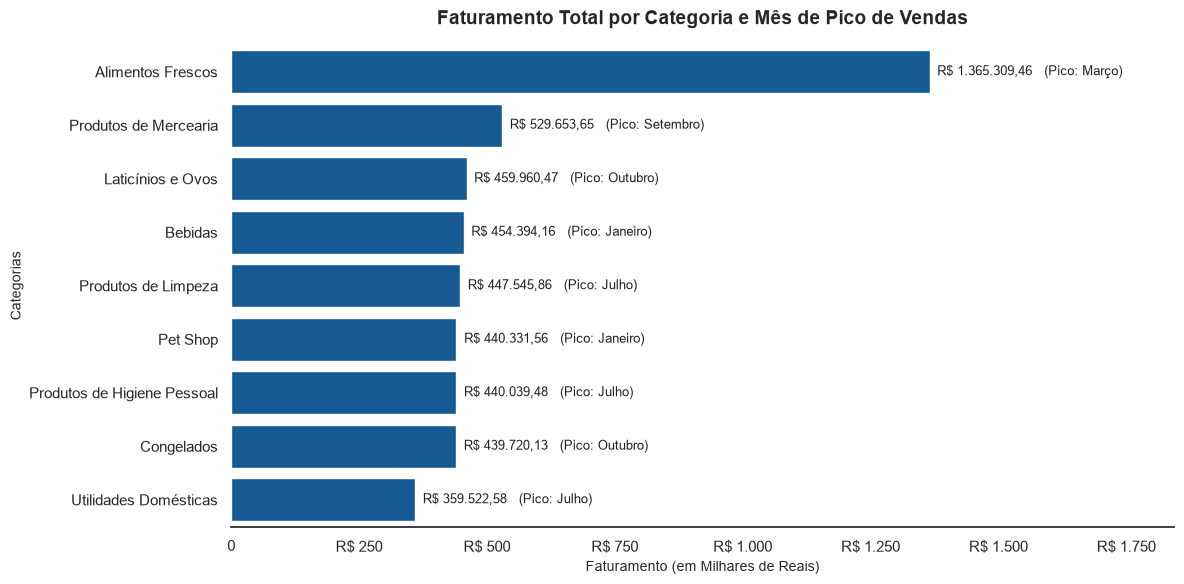

In [293]:
# Gráfico P1- Faturamento Total por Categoria e Mês de Pico de Vendas
p1_df['Faturado_k'] = p1_df['Total_Faturado'] / 1e3

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(
    data=p1_df,
    y='Categoria',
    x='Faturado_k',
    color=COR_PRINCIPAL,
    ax=ax
)

for i, row in p1_df.iterrows():
    texto=f'{formata_br(row['Total_Faturado'])}   (Pico: {row['Mes_Pico']})'
    ax.text(
        row['Faturado_k'] + 15,
        i,
        texto,
        va='center',
        ha='left',
        fontsize=9,
        color='#222222'
    )

    ax.set_title('Faturamento Total por Categoria e Mês de Pico de Vendas', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Faturamento (em Milhares de Reais)', fontsize=10)
    ax.set_ylabel('Categorias', fontsize=10)
    ax.set_xlim(0, p1_df['Faturado_k'].max() * 1.35)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x)}' if x> 0 else '0'))
    ax.set_xticks(range(0, 1751, 250))

sns.despine(ax=ax, top=True, right=True, left=True)
fig.tight_layout()

plt.savefig(
    r'../reports/p1_faturamento_total_por_categoria_e_mes_de_pico_de_vendas.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.show()

> **PRODUTOS MAIS VENDIDOS E MESES DE PICO DE VENDAS:** Os produtos que tiveram maiores vendas foram ALIMENTOS FRESCOS (1.365 Milhão), PRODUTOS DE MERCEARIA (529 Mil) e LATICÍNIOS E OVOS (459 Mil), tendo os picos de vendas nos meses Março, Setembro e Outubro respectivamente.

#### **2.** Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?


In [255]:
df_produtos_promocao =  df.groupby(['Produto', 'Com_Desconto'])['Quantidade'].mean().unstack()
df_produtos_promocao['Aumento_Pct'] = ((df_produtos_promocao[True] / df_produtos_promocao[False]) - 1 ).mul(100)
df_produtos_promocao = df_produtos_promocao.sort_values(by='Aumento_Pct', ascending=False).head(10).reset_index()

print(f'\n--- P2: Top 10 Produtos com Maior Aumento de Quantidade em Promoções ---')
display(df_produtos_promocao)


--- P2: Top 10 Produtos com Maior Aumento de Quantidade em Promoções ---


Com_Desconto,Produto,False,True,Aumento_Pct
0,Frango,9.99,11.38,13.93
1,Farinha,9.81,11.05,12.63
2,Bananas,9.33,10.33,10.72
3,Azeite,9.81,10.80,10.08
4,Talheres,10.18,11.13,9.39
5,Maçãs,10.16,11.03,8.57
6,Tilápia,9.68,10.46,8.04
7,Papel higiênico,9.94,10.68,7.51
8,Salmão,9.85,10.49,6.45
9,Leite,10.44,11.08,6.09


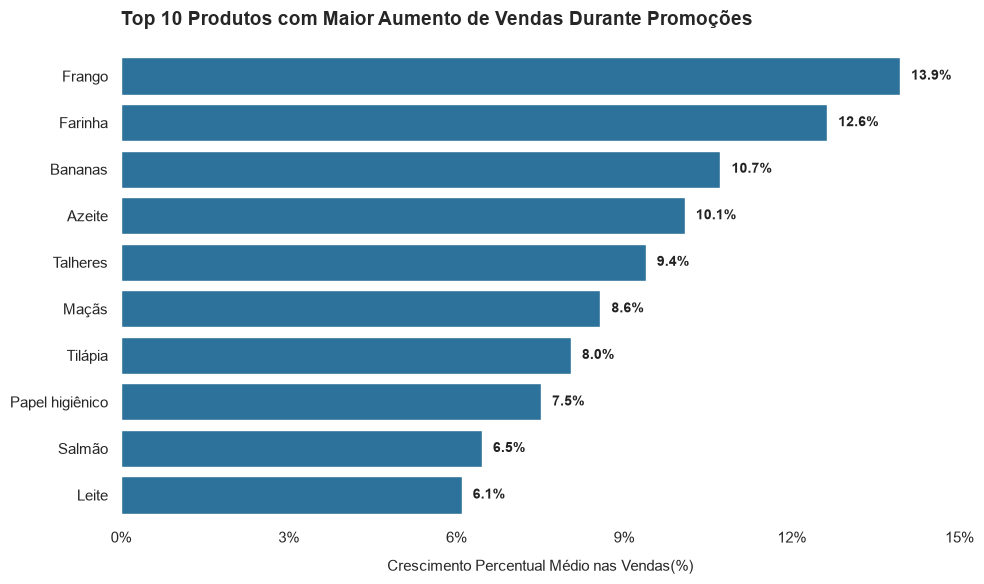

In [256]:
# Gráfico P2 - Top 10 Produtos com Maior Aumento de Vendas Durante Promoções
fig, ax = plt.subplots(figsize=(10, 6))

barplot = sns.barplot(
    data= df_produtos_promocao,
    x='Aumento_Pct',
    y='Produto',
    color='#1b77ac',
    ax=ax
)

# Rótulos
for p in barplot.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.1f}%',
        (width, p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        xytext = (8, 0),
        textcoords = 'offset points',
        fontsize=10,
        fontweight='bold',
        color='#222222'
    )

    ax.set_title(
        'Top 10 Produtos com Maior Aumento de Vendas Durante Promoções',
        fontsize=14,
        fontweight='bold',
        pad=20,
        loc='left'
    ),

ax.set_xlabel('Crescimento Percentual Médio nas Vendas(%)', fontsize=11, labelpad=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{(x)}%'))
ax.set_ylabel('')

ax.set_xlim(0, max(df_produtos_promocao['Aumento_Pct']) * 1.05)
ax.set_xticks(range(0, 16, 3))

sns.despine(left=True, bottom=True)

plt.savefig(
    r'../reports/p2_top_10_produtos_com_maior_aumento_de_vendas_durante_promocoes.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()    

#### **3.** Qual a média de vendas diárias por categoria de produto?

In [257]:
media_diaria_categoria = df.groupby(['Categoria','Data'])['Total_Venda'].sum().groupby('Categoria').mean()
media_diaria_categoria = media_diaria_categoria.sort_values(ascending=False).reset_index().rename(columns={'Total_Venda': 'Media_Diaria'})
media_diaria_categoria['Percentual'] = (media_diaria_categoria['Media_Diaria'] / media_diaria_categoria['Media_Diaria'].sum()).mul(100).round(2)
print(f'\n--- P3: Média de Vendas Diárias por Categoria ---')
display(media_diaria_categoria)


--- P3: Média de Vendas Diárias por Categoria ---


,Categoria,Media_Diaria,Percentual
0,Alimentos Frescos,"3,740.57",27.66
1,Produtos de Mercearia,"1,451.11",10.73
2,Laticínios e Ovos,"1,260.17",9.32
3,Bebidas,"1,244.92",9.20
4,Produtos de Limpeza,"1,226.15",9.07
5,Pet Shop,"1,206.39",8.92
6,Produtos de Higiene Pessoal,"1,205.59",8.91
7,Congelados,"1,204.71",8.91
8,Utilidades Domésticas,984.99,7.28


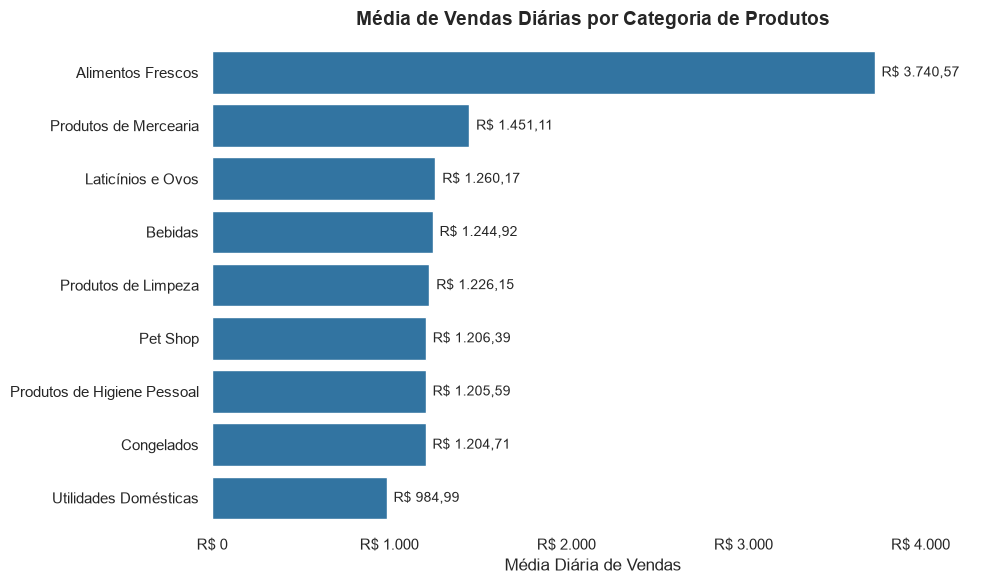

In [258]:
# Gráfico P3 - Média de Vendas Diárias por Categoria de Produtos
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=media_diaria_categoria,
    x='Media_Diaria',
    y='Categoria',
    color='#1f77b4'
)

# Rótulos
ax.bar_label(
    ax.containers[0],
    labels= [f'{formata_br(v)}' for v in media_diaria_categoria['Media_Diaria']],
    #fmt='R$ %.2f',
    padding=5,
    fontsize=10
    )

plt.title('Média de Vendas Diárias por Categoria de Produtos', fontsize=14, pad=15, weight='bold')
plt.xlabel('Média Diária de Vendas')
plt.ylabel('')
plt.xlim(0,media_diaria_categoria['Media_Diaria'].max() * 1.15)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x)}'))
ax.set_xticks(range(0, 4001, 1000))

sns.despine(left=True, bottom=True)

plt.savefig(
    r'../reports/p3_media_de_vendas_diarias_por_categoria_de_produtos.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **4.** Quais produtos apresentam maior sazonalidade nas vendas (ex: frutas e vegetais, sorvetes)?
a. Para responder essa pergunta considere a medida de sazonalidade dada pelo coeficiente de variação mensal.

In [259]:
vendas_produto_mes = df.groupby(['Produto','Mes'])['Total_Venda'].sum().unstack()
#display(vendas_produto_mes)

desvio_padrao = vendas_produto_mes.std(axis=1)
media = vendas_produto_mes.mean(axis=1)
cv = (desvio_padrao / media).mul(100)

df_sazonal = (
    cv.sort_values(ascending=False)
    .reset_index(name='CV')
    .head(10)
)

print(f'\n--- P4: Top 10 Produtos com Maior Sazonalidade (CV) ---')
display(df_sazonal)


--- P4: Top 10 Produtos com Maior Sazonalidade (CV) ---


,Produto,CV
0,"Produtos descartáveis (pratos, copos, talheres)",23.07
1,Vinhos,22.98
2,Sucos,22.87
3,Atum,22.52
4,Tomates,22.33
5,Refrigerantes,21.84
6,Croissants,21.58
7,Ração para gatos,20.67
8,Cervejas,20.02
9,Alface,19.88


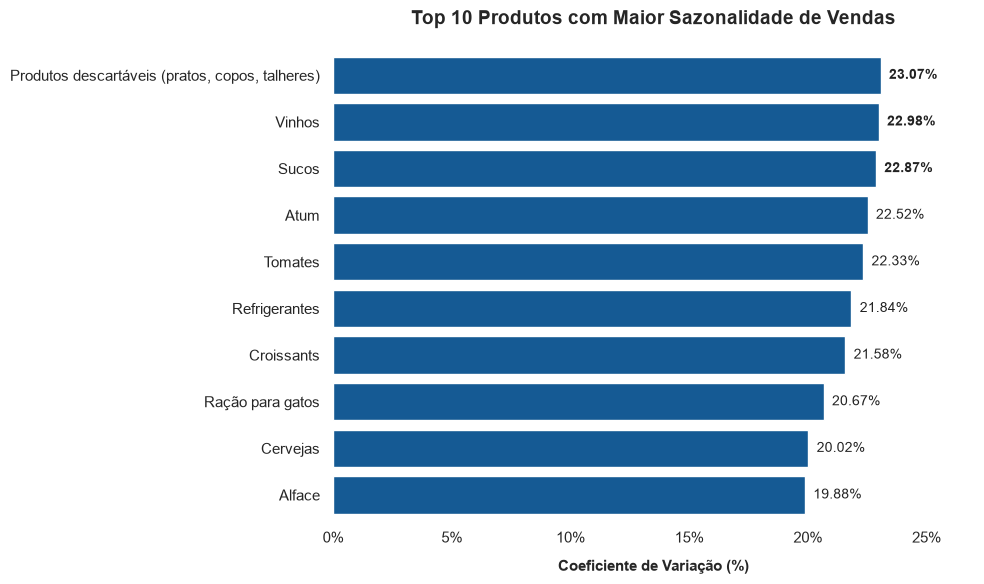

In [260]:
# Gráfico P4 - Top 10 Produtos com Maior Sazonalidade de Vendas

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_sazonal,
    x='CV',
    y='Produto',
    color=f'{COR_PRINCIPAL}',
    ax=ax
)

ax.set_title('Top 10 Produtos com Maior Sazonalidade de Vendas', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Coeficiente de Variação (%)', fontsize=11, fontweight='bold',labelpad=10)
ax.set_ylabel('')

ax.set_xlim(0,27)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:.2f}%',
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold' if width >= 22.867 else 'normal',
        color='#222222'
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{(x)}%'))
ax.set_xticks(range(0, 26, 5))

sns.despine(top=True, right=True, left=True, bottom=True)
#ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(False)

plt.savefig(
    r'../reports/p4_1_top_10_produtos_com_maior_sazonalidade_de_vendas.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

In [261]:
top_10_list_produtos = df_sazonal['Produto'].tolist()
mes_ordem = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho','Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']
dados_grafico = vendas_produto_mes.loc[top_10_list_produtos].T.reindex(mes_ordem)

display(dados_grafico)

Produto,"Produtos descartáveis (pratos, copos, talheres)",Vinhos,Sucos,Atum,Tomates,Refrigerantes,Croissants,Ração para gatos,Cervejas,Alface
Mes,,,,,,,,,,
Janeiro,"9,232.09","9,927.97","11,633.90","8,744.65","11,492.61","11,476.63","7,409.31","9,640.86","6,715.17","9,757.76"
Fevereiro,"9,393.87","8,601.99","6,103.49","11,005.68","5,538.50","8,530.40","8,606.93","9,596.97","8,100.44","7,983.28"
Março,"5,652.67","7,040.50","7,275.44","9,425.18","7,847.20","7,681.16","9,105.62","6,129.09","6,710.23","9,139.99"
Abril,"6,669.05","5,256.16","8,330.50","8,566.06","5,134.43","6,596.69","4,737.92","6,989.49","5,511.59","6,960.46"
Maio,"6,526.22","8,902.52","7,588.08","7,244.06","7,446.00","10,103.57","7,434.47","6,032.49","5,718.21","5,607.81"
Junho,"10,006.62","5,985.97","7,823.86","9,018.79","9,403.97","7,380.49","8,419.95","7,722.89","9,754.46","6,871.83"
Julho,"8,864.58","10,335.43","9,024.81","7,953.24","8,564.10","7,235.10","9,355.28","7,005.30","8,911.73","10,690.73"
Agosto,"5,741.41","5,885.34","7,460.80","7,117.70","7,018.97","5,939.23","9,962.48","6,409.16","8,724.39","5,872.97"
Setembro,"5,728.02","5,952.48","5,331.01","6,155.13","6,688.08","6,768.40","6,899.61","6,410.61","7,166.54","8,941.25"


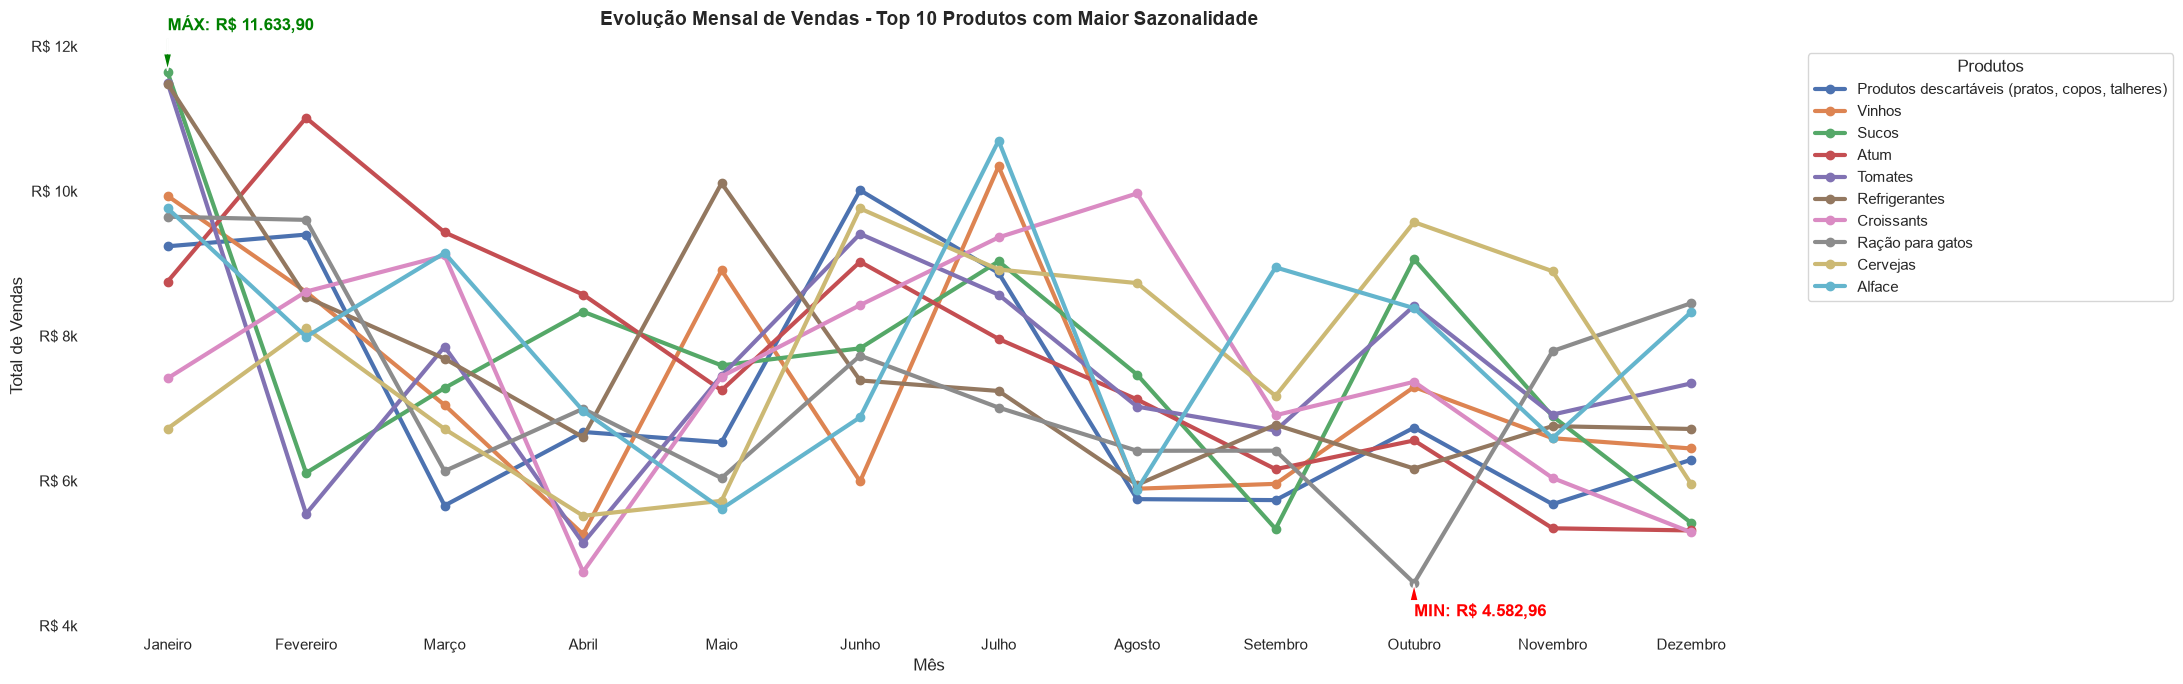

In [262]:
# Gráfico P4 - Evolução Mensal de Vendas - Top 10 Produtos com Maior Sazonalidade
fig, ax = plt.subplots(figsize=(22,7))
for produto in dados_grafico.columns:
    ax.plot(
        dados_grafico.index,
        dados_grafico[produto],
        marker='o',
        linewidth=3,
        label=produto
    )

val_max = dados_grafico.max().max()
col_max= dados_grafico.max().idxmax()
idx_max = dados_grafico[col_max].idxmax()

ax.annotate(
    f'MÁX: {formata_br(val_max)}',
    xy=(idx_max, val_max),
    xytext=(idx_max, val_max + (val_max * 0.05)),
    arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6),
    fontweight='bold',
    color='green',
    ha='left',
)

val_min = dados_grafico.min().min()
col_min= dados_grafico.min().idxmin()
idx_min = dados_grafico[col_min].idxmin()

ax.annotate(
    f'MIN: {formata_br(val_min)}',
    xy=(idx_min, val_min),
    xytext=(idx_min, val_min - (val_min * 0.1)),
    arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
    fontweight='bold',
    color='red',
    ha='left',
)


ax.set_title('Evolução Mensal de Vendas - Top 10 Produtos com Maior Sazonalidade', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Total de Vendas', fontsize=12)
ax.set_xticks(dados_grafico.index)
#
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x/1000)}k'))
ax.set_yticks(range(4000, 12001, 2000))

ax.legend(title='Produtos', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)


sns.despine(top=True, right=True, left=True, bottom=True)

plt.savefig(
    r'../reports/p4_2_evolucao_mensal_de_vendas__top_10_produtos_com_maior_sazonalidade.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **5.** Quais as faixas etárias contuibuíram mais para as vendas totais?
a. Para responder essa pergunta crie uma coluna com a faixa etária, considerando: entre 18 e 35(jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso).

In [263]:
df_vendas_faixa_etaria = df.groupby(['Faixa_Etaria'])['Total_Venda'].agg(['sum','mean','count']).reset_index()
df_vendas_faixa_etaria['pct'] = (df_vendas_faixa_etaria['sum'] / df['Total_Venda'].sum()).mul(100).round(2)
df_vendas_faixa_etaria = df_vendas_faixa_etaria.rename(columns={'sum':'Total_Venda','mean':'Media','count':'Quantidade','pct':'Percentual'})
print(f'\n--- P5: Contribuição por Faixa Etária ---')
display(df_vendas_faixa_etaria)


--- P5: Contribuição por Faixa Etária ---


,Faixa_Etaria,Total_Venda,Media,Quantidade,Percentual
0,Jovem (18-35),"1,537,183.38",242.19,6347,31.14
1,Adulto (36-59),"2,102,041.77",247.79,8483,42.58
2,Idoso (60+),"1,297,252.20",247.33,5245,26.28


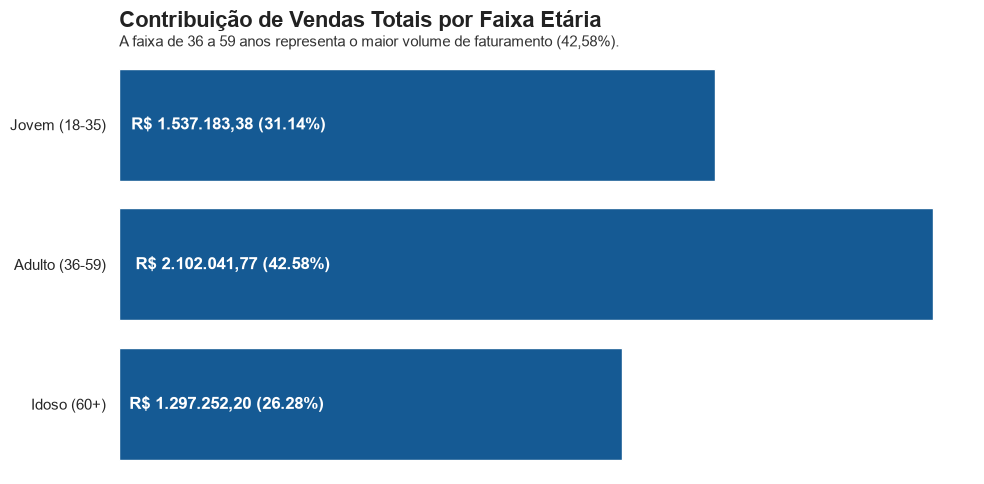

In [264]:
# Gráfico P5 - Contribuição de Vendas Totais por Faixa Etária
plt.figure(figsize=(10, 5))

cores = [
    '#a6b9ce' if x != df_vendas_faixa_etaria['Total_Venda'].max() else '#1d4ed8' for x in df_vendas_faixa_etaria['Total_Venda']
]

ax = sns.barplot(
    data=df_vendas_faixa_etaria,
    x='Total_Venda',
    y='Faixa_Etaria',
    #palette=cores,
    color=f'{COR_PRINCIPAL}'
    #hue='Faixa_Etaria',
    #legend=False,
)

for i, row in df_vendas_faixa_etaria.iterrows():
    texto = f'{formata_br(row['Total_Venda'])} ({row['Percentual']:.2f}%)'

    ax.text(
        x=row['Total_Venda'] * 0.02,
        y=i,
        s=texto,
        va='center',
        ha='left',
        fontsize=12,
        fontweight='bold',
        #color='white' if row['Total_Venda'] == df_vendas_faixa_etaria['Total_Venda'].max() else '#1e293b'
        color='#ffffff'
    )
 
ax.set_title(
    'Contribuição de Vendas Totais por Faixa Etária',
    fontsize=16,
    fontweight='bold',
    pad=20,
    loc='left',
    color='#222222',
)

ax.text(
    0,
    1.02,
    'A faixa de 36 a 59 anos representa o maior volume de faturamento (42,58%).',
    transform=ax.transAxes,
    fontsize=11,
    color='#333333',
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
sns.despine(top=True, right=True, left=True, bottom=True)

plt.savefig(
    r'../reports/p5_contribuicao_de_vendas_totais_por_faixa_etaria.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **6.** Qual a distribuição das vendas ao longo dos dias da semana?

In [265]:
dias_ordem = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
#vendas_dia = df.groupby('Dia_Semana')['Total_Venda'].agg(['sum','mean']).reindex(dias_ordem).reset_index(drop=False)
vendas_dia = df.groupby('Dia_Semana')['Total_Venda'].agg(['count','sum','mean','median','min','max','std']).reindex(dias_ordem).reset_index(drop=False)
vendas_dia['pct'] = (vendas_dia['sum'] / df['Total_Venda'].sum()).mul(100).round(2).astype(str) + '%'
print(f'\n--- P6: Vendas por Dia da Semana ---')
display(vendas_dia)


--- P6: Vendas por Dia da Semana ---


,Dia_Semana,count,sum,mean,median,min,max,std,pct
0,Segunda,2860,"695,777.31",243.28,186.15,1.05,948.48,206.66,14.09%
1,Terça,2860,"686,277.94",239.96,183.82,1.26,948.10,202.10,13.9%
2,Quarta,2860,"710,052.02",248.27,186.54,0.91,948.67,211.92,14.38%
3,Quinta,2860,"706,311.13",246.96,185.51,0.95,945.82,205.76,14.31%
4,Sexta,2860,"707,290.91",247.30,189.70,1.95,944.68,208.22,14.33%
5,Sábado,2860,"707,984.37",247.55,183.93,1.06,940.88,209.91,14.34%
6,Domingo,2915,"722,783.68",247.95,187.95,1.02,949.05,209.73,14.64%


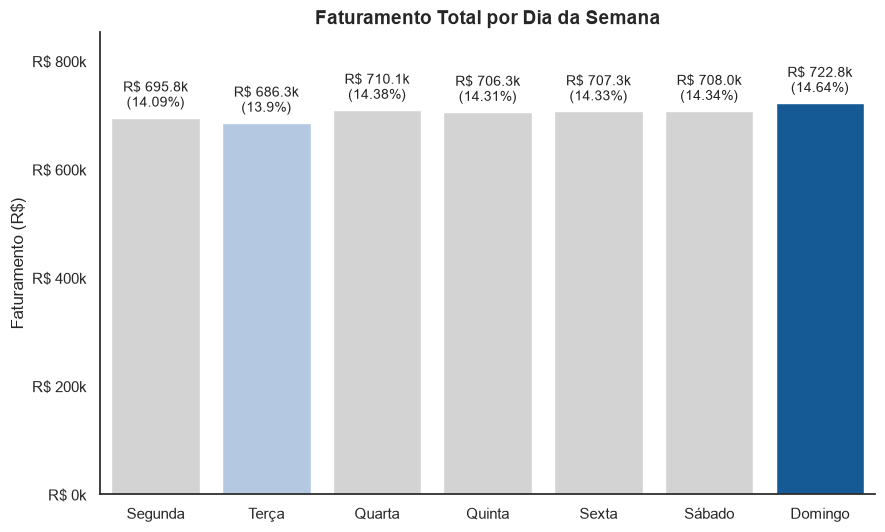

In [266]:
# Grafico P6 - Faturamento Total por Dia da Semana
fig, ax = plt.subplots(figsize=(10,6))

cores = [f'{COR_PRINCIPAL}' if dia == 'Domingo' else '#aec7e8' if dia == 'Terça' else '#d3d3d3'
         for dia in vendas_dia['Dia_Semana']]
barras = sns.barplot(
    data=vendas_dia,
    x='Dia_Semana',
    y='sum',
    palette=cores,
    hue='Dia_Semana',
    legend=False,
    ax=ax
)

# Rótulos
for p, pct in zip(barras.patches, vendas_dia['pct']):
    val_k = p.get_height() / 1000
    ax.annotate(
        f'R$ {val_k:,.1f}k\n({pct})',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        color='#222222'
    )

    # Títulos
    ax.set_title('Faturamento Total por Dia da Semana', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Faturamento (R$)')
    ax.set_ylim(0,vendas_dia['sum'].max() * 1.18)
    sns.despine()

    #ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'R$ {int(x/1000)}k' if x> 0 else '0'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x/1000)}k'))

    plt.savefig(
    r'../reports/p6_faturamento_total_por_dia_da_semana.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)
    
    ax.set_yticks(range(0, 800_001, 200_000))


#### **7.** Como as vendas mensais se comparam antes e durante a Black Friday?

In [267]:
vendas_mensais = df.groupby('Mes')['Total_Venda'].sum()
print(f'\n--- P7: Faturamento Total por Mês ---')
dados = vendas_mensais.loc[['Outubro', 'Novembro']].reset_index()
display(dados)


--- P7: Faturamento Total por Mês ---


,Mes,Total_Venda
0,Outubro,"416,884.85"
1,Novembro,"385,743.38"


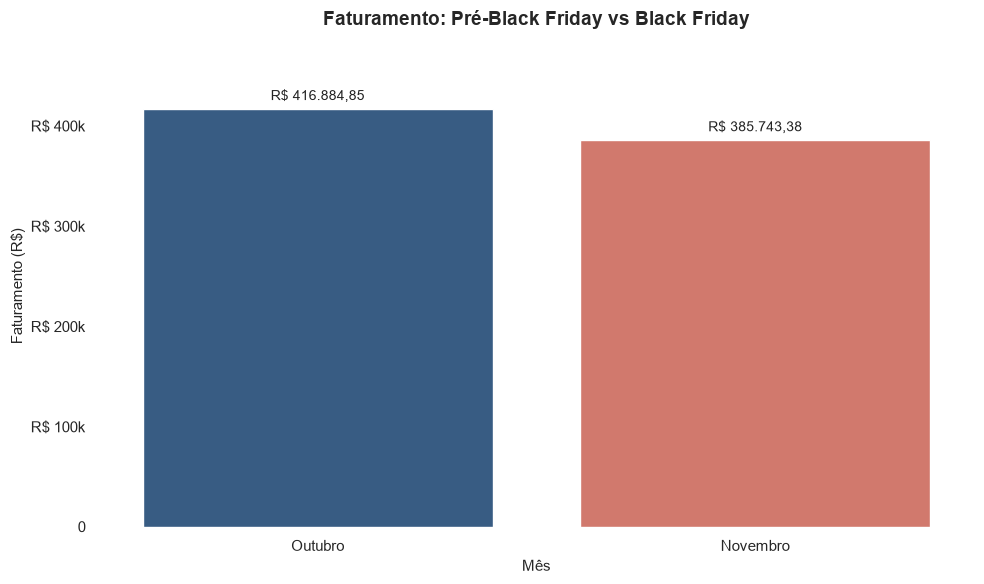

In [292]:
# Gráfico P7 - Faturamento: Pré-Black Friday vs Black Friday
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=dados,
    x='Mes',
    y='Total_Venda',
    hue='Mes',
    palette=['#2b5c8f','#e26d5c'],
    legend=False
)

# Rótulos
for p in ax.patches:
    ax.annotate(
        f'{formata_br(p.get_height())}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        color='#222222',
        xytext=(0, 4),
        textcoords='offset points'
    )

# Títulos
ax.set_title('Faturamento: Pré-Black Friday vs Black Friday', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Faturamento (R$)', fontsize=11)
ax.set_ylim(0, dados['Total_Venda'].max() * 1.15)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'R$ {int(x/1000)}k' if x> 0 else '0'))
sns.despine(top=True, right=True, left=True, bottom=True)

plt.savefig(
    r'../reports/p7_faturamento_preblack_friday_vs_black_friday.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)
plt.tight_layout()
plt.show()



#### **8.** Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre diferentes categorias de produto?

In [269]:
ticket_faixa_categoria = df.groupby(['Faixa_Etaria','Categoria'])['Total_Venda'].mean().unstack()
print('\n--- P8: Ticket Médio por Faixa Etária e Categoria ---')
ticket_faixa_categoria = ticket_faixa_categoria.T
display(ticket_faixa_categoria)

print((ticket_faixa_categoria.columns))


--- P8: Ticket Médio por Faixa Etária e Categoria ---


Faixa_Etaria,Jovem (18-35),Adulto (36-59),Idoso (60+)
Categoria,,,
Alimentos Frescos,241.41,253.66,251.97
Bebidas,249.46,240.42,261.24
Congelados,234.94,245.67,240.42
Laticínios e Ovos,252.19,249.26,256.35
Pet Shop,237.33,247.80,234.93
Produtos de Higiene Pessoal,237.54,244.52,240.05
Produtos de Limpeza,245.42,249.26,238.87
Produtos de Mercearia,238.58,242.30,245.31
Utilidades Domésticas,246.16,246.39,246.13


CategoricalIndex(['Jovem (18-35)', 'Adulto (36-59)', 'Idoso (60+)'], categories=['Jovem (18-35)', 'Adulto (36-59)', 'Idoso (60+)'], ordered=True, dtype='category', name='Faixa_Etaria')


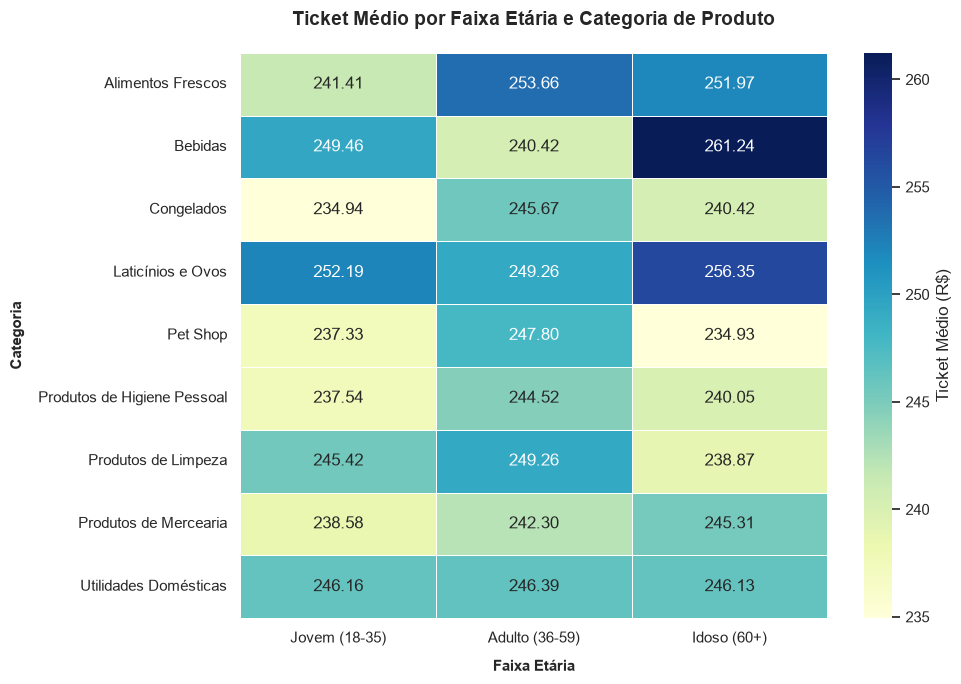

In [270]:
# Gráfico P8 - Ticket Médio por Faixa Etária e Categoria de Produto
plt.figure(figsize=(10,7))

ax = sns.heatmap(
    ticket_faixa_categoria,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label':'Ticket Médio (R$)'},
)

plt.title(
    'Ticket Médio por Faixa Etária e Categoria de Produto',
    fontsize=14,
    pad=20,
    weight='bold',
)

plt.xlabel('Faixa Etária', fontsize=11, labelpad=10, weight='bold')
plt.ylabel('Categoria', fontsize=11, labelpad=10, weight='bold')

plt.savefig(
    r'../reports/p8_ticket_medio_por_faixa_etaria_e_categoria_de_produto.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **9.** Qual a relação entre a idade dos clientes e o valor total das compras?

In [271]:
correlacao_idade_total_venda = df['Idade'].corr(df['Total_Venda'])
print(f'\n--- P9: Coeficiente de Correlação (Idade vs Total Venda): {correlacao_idade_total_venda:.4f} ---')


--- P9: Coeficiente de Correlação (Idade vs Total Venda): 0.0077 ---


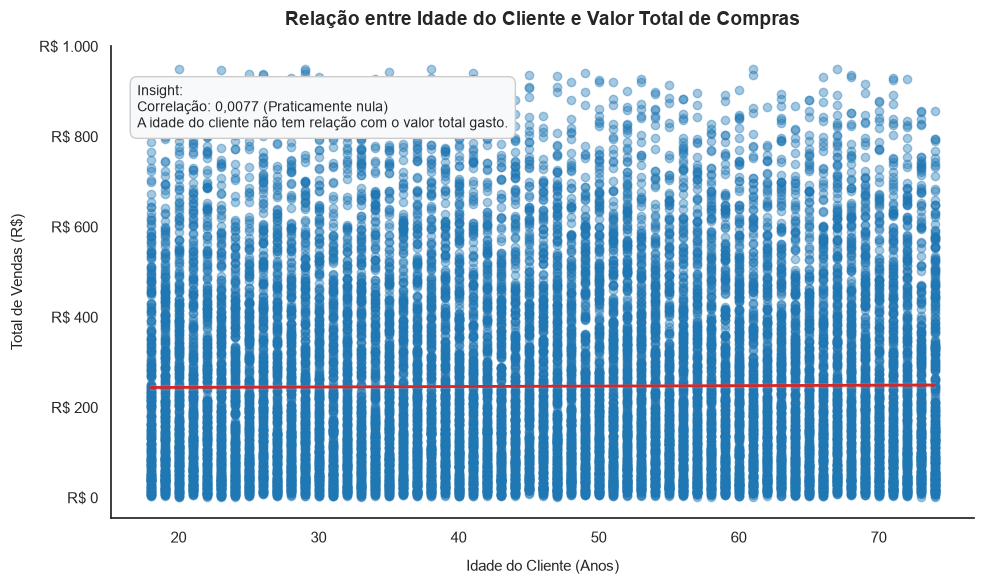

In [272]:
# Gráfico P9 - Relação entre Idade do Cliente e Valor Total de Compras
plt.figure(figsize=(10, 6))

ax = sns.regplot(
    data=df,
    x='Idade',
    y='Total_Venda',
    scatter_kws={'alpha': 0.4, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plt.title(
    'Relação entre Idade do Cliente e Valor Total de Compras',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Idade do Cliente (Anos)', fontsize=11, labelpad=10)
plt.ylabel('Total de Vendas (R$)', fontsize=11, labelpad=10)

insight_text = (
    'Insight:\n'
    'Correlação: 0,0077 (Praticamente nula)\n'
    'A idade do cliente não tem relação com o valor total gasto.'
)

plt.gca().text(
    0.03,
    0.92,
    insight_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round, pad=0.5', facecolor='#f8f9fa', edgecolor='#cccccc')
)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x)}'))
ax.set_yticks(range(0, 1001, 200))

sns.despine()

plt.savefig(
    r'../reports/p9_relacao_entre_idade_do_cliente_e_valor_total_de_compras.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **10.** Comparando a semana da Black Friday com a do Natal, qual semana a empresa teve melhores desempenhos em média de vendas?

In [273]:
# Black Friday 2023 (20/11 a 26/11) vs Natal 2023 (19/12 a 25/12)
vendas_black_friday = df[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26')].groupby('Data')['Total_Venda'].sum().to_frame().reset_index()
vendas_natal = df[(df['Data'] >= '2023-12-19') & (df['Data'] <= '2023-12-25')].groupby('Data')['Total_Venda'].sum().to_frame().reset_index()
vendas_black_friday['Dia'] = ['Dia 1','Dia 2','Dia 3','Dia 4','Dia 5','Dia 6','Dia 7']
vendas_natal['Dia'] = ['Dia 1','Dia 2','Dia 3','Dia 4','Dia 5','Dia 6','Dia 7']
vendas_black_friday['Evento'] = 'Black Friday'
vendas_natal['Evento'] = 'Natal'

df_compara_bf_natal = pd.concat([vendas_black_friday, vendas_natal], ignore_index=True)


total_bf = vendas_black_friday['Total_Venda'].sum().round(2)
total_natal = vendas_natal['Total_Venda'].sum().round(2)
media_bf = vendas_black_friday['Total_Venda'].mean().round(2)
media_natal = vendas_natal['Total_Venda'].mean().round(2)

print(f'\n--- P10')
print('\nVendas diárias durante a semana do Black Friday')
print(vendas_black_friday)

print('\nVendas diárias durante a semana do Natal')
print(vendas_natal)

print(f'\nTotal vendas na semana da Black Friday: R$ {total_bf}')
print(f'Média diária de vendas na semana da Black Friday: R$ {media_bf}')
print(f'\nTotal vendas na semana do Natal: R$ {total_natal}')
print(f'Média diária de vendas na semana do Natal: R$ {media_natal}')

print( (media_natal / media_bf))



--- P10

Vendas diárias durante a semana do Black Friday
        Data  Total_Venda    Dia        Evento
0 2023-11-20    11,908.89  Dia 1  Black Friday
1 2023-11-21    12,131.54  Dia 2  Black Friday
2 2023-11-22    14,569.10  Dia 3  Black Friday
3 2023-11-23     9,647.64  Dia 4  Black Friday
4 2023-11-24     9,801.83  Dia 5  Black Friday
5 2023-11-25     8,561.80  Dia 6  Black Friday
6 2023-11-26     9,831.27  Dia 7  Black Friday

Vendas diárias durante a semana do Natal
        Data  Total_Venda    Dia Evento
0 2023-12-19    15,280.43  Dia 1  Natal
1 2023-12-20    12,046.08  Dia 2  Natal
2 2023-12-21    12,290.98  Dia 3  Natal
3 2023-12-22    11,753.79  Dia 4  Natal
4 2023-12-23    10,267.28  Dia 5  Natal
5 2023-12-24    12,702.03  Dia 6  Natal
6 2023-12-25    11,850.63  Dia 7  Natal

Total vendas na semana da Black Friday: R$ 76452.08
Média diária de vendas na semana da Black Friday: R$ 10921.73

Total vendas na semana do Natal: R$ 86191.23
Média diária de vendas na semana do Natal: 

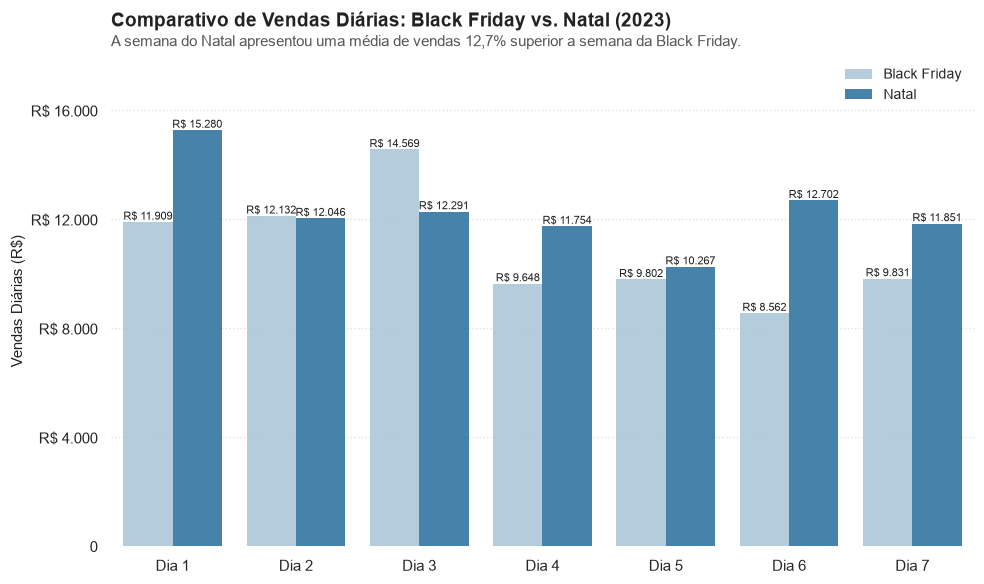

In [274]:
# Gráfico P10 - Comparativo de Vendas Diárias: Black Friday vs. Natal (2023)
fig, ax = plt.subplots(figsize=(10, 6))

cores = {'Black Friday': '#a6c8e0', 'Natal': '#1f77b4'}

barplot = sns.barplot(
    data=df_compara_bf_natal,
    x='Dia',
    y='Total_Venda',
    hue='Evento',
    palette=cores,
    ax=ax,
    edgecolor='none',
    alpha=0.9,   
)

""" [ax.axhline(
    media_bf,
    color= '#a6c8e0',
    linestyle= '--',
    linewidth=1.5,
    alpha=0.4,
    label=f'Média Black Friday (R$ {formata_br(media_bf)})'
)

ax.axhline(
    media_natal,
    color= '#1f77b4',
    linestyle='--',
    linewidth=1.5,
    alpha=0.4,
    label=f'Média Natal (R$ {formata_br(media_natal)})'
)] """

#Títulos e Rótulos
ax.set_title(
    'Comparativo de Vendas Diárias: Black Friday vs. Natal (2023)\n',
    fontsize=14,
    fontweight='bold',
    loc='left',
    color='#222222'
)

ax.text(
    0,
    1.02,
    'A semana do Natal apresentou uma média de vendas 12,7% superior a semana da Black Friday.',
    transform=ax.transAxes,
    fontsize=11,
    color='#555555',
)

ax.set_xlabel('')
ax.set_ylabel('Vendas Diárias (R$)', fontsize=11, color='#222222')
ax.set_ylim(0, 18000)

#Rotulos de valores
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{formata_br_inteiro(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8,
            color='#222222',
        )

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{formata_br_inteiro(x)}' if x> 0 else '0'))
ax.set_yticks(range(0, 16001, 4000))

sns.despine(top=True, right=True, left=True, bottom=True)
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(frameon=False, loc='upper right', fontsize=10)


plt.savefig(
    r'../reports/p10_comparativo_de_vendas_diarias_black_friday_vs_natal_2023.png',
    dpi=300,
    bbox_inches='tight',
    transparent=False
)

plt.tight_layout()
plt.show()

#### **11.** O aumento nas vendas durante períodos de promoção (descontos) é estatisticamente significativo, ou pode ser explicado por variação aleatória? Utilize A/B comparando o valor médio das vendas do grupo com desconto (B) contra o grupo sem desconto (A).

In [275]:
def verificar_normalidade(amostra, alpha=0.05):
    stat, p = stats.shapiro(amostra.dropna())

    if p > alpha: 
        resultado = "Distribuição normal (Teste de Shapiro)"
    else:
        resultado = 'Distribuição não normal (Teste de Shapiro)'
    return stat, p, resultado

def verificar_homocedasticidade(amostra_1, amostra_2, alpha=0.05):
    stat, p, = stats.levene(amostra_1, amostra_2)

    if p > alpha:
        resultado = 'Amostras possuem homogeneidade de variância (Teste de Levene)'
    else: 
        resultado = 'Amostras não possuem homogeneidade de variância (Teste de Levene)'
    return stat, p, resultado

alpha = 0.05
grupo_a = df[~df['Com_Desconto']]['Total_Venda']
grupo_b = df[df['Com_Desconto']]['Total_Venda']


print('\n--- Teste U Mann-Whitney (Teste não paramétrico): (Promoção A/B)')
print(f'Média Sem Desconto (Grupo A): R$ {grupo_a.mean():.2f} | Normalidade: {verificar_normalidade(grupo_a,alpha)[2]}')
print(f'Média Com Desconto (Grupo B): R$ {grupo_b.mean():.2f} | Normalidade: {verificar_normalidade(grupo_b,0.05)[2]}')
print(f'\nHomocedasticidade: {verificar_homocedasticidade(grupo_a, grupo_b)[2]}')

u_stat, p_valor = stats.mannwhitneyu(grupo_b, grupo_a, alternative='greater')

print(f'\nEstatística t: {u_stat}')
print(f'p-valor: {p_valor}')
if p_valor < alpha:
    print('\nCONCLUSÃO: O aumento é estatisticamente significativo. Rejeita-se a hipótese nula (H0).')
    print('A diferença observada não pode ser explicada por variação aleatória.')
else:
    print('\nCONCLUSÃO: Não há evidência estatística significativa de aumento. Não se rejeita a hipótese nula (H0).')
    print('A diferença observada pode decorrer de variação aleatória.')


--- Teste U Mann-Whitney (Teste não paramétrico): (Promoção A/B)
Média Sem Desconto (Grupo A): R$ 256.41 | Normalidade: Distribuição não normal (Teste de Shapiro)
Média Com Desconto (Grupo B): R$ 205.93 | Normalidade: Distribuição não normal (Teste de Shapiro)

Homocedasticidade: Amostras não possuem homogeneidade de variância (Teste de Levene)

Estatística t: 29110752.0
p-valor: 1.0

CONCLUSÃO: Não há evidência estatística significativa de aumento. Não se rejeita a hipótese nula (H0).
A diferença observada pode decorrer de variação aleatória.


c:\workspace\_python\caixaverso_projeto_eda\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15895.
  res = hypotest_fun_out(*samples, **kwds)


#### **12.** O desempenho de vendas da semana da Black Friday é estatisticamente diferente do desempenho da semana do Natal (pergunta 10), ou a diferença pode ser explicada por variação natural entre semanas? Utilize um teste A/B (teste t para duas amostras independentes) comparando as vendas diárias das duas semanas, e construa também intervalos de confiaça de 95% para a média de vendas diárias de cada uma.

In [276]:
# Dados diários Semana Black Friday e Natal
vendas_black_friday = df[(df['Data'] >= '2023-11-20') & (df['Data'] <= '2023-11-26')].groupby('Data')['Total_Venda'].sum()
vendas_natal = df[(df['Data'] >= '2023-12-19') & (df['Data'] <= '2023-12-25')].groupby('Data')['Total_Venda'].sum()

# Teste t independente
t_stat, p_valor = stats.ttest_ind(vendas_black_friday, vendas_natal, equal_var=False)
alpha = 0.05

# Intervalos de Confiança (95%)
ic_vendas_black_friday = stats.t.interval(0.95, df=len(vendas_black_friday)-1, loc=vendas_black_friday.mean(), scale=stats.sem(vendas_black_friday))
ic_vendas_natal = stats.t.interval(0.95, df=len(vendas_natal)-1, loc=vendas_natal.mean(), scale=stats.sem(vendas_natal))

print(f'IC 95% Black Friday: R$ {ic_vendas_black_friday[0]:.2f} a R$ {ic_vendas_black_friday[1]:.2f}')
print(f'IC 95% Natal: R$ {ic_vendas_natal[0]:.2f} a R$ {ic_vendas_natal[1]:.2f}')
print(f'\nEstatística t: {t_stat:.4f} | p-valor: {p_valor:.4f}')

if p_valor < alpha:
    print('\nCONCLUSÃO: O aumento é estatisticamente significativo (rejeita-se a hipótese nula H0).')
    print('A diferença observada não pode ser explicada por variação aleatória.')
else:
    print('\nCONCLUSÃO: Não há evidência estatística de aumento significativo entre as médias (não se rejeita a hipótese nula H0).')
    print('A diferença observada entre as médias pode decorrer puramente de variação aleatória.')

IC 95% Black Friday: R$ 9019.70 a R$ 12823.75
IC 95% Natal: R$ 10913.48 a R$ 13712.59

Estatística t: -1.4417 | p-valor: 0.1772

CONCLUSÃO: Não há evidência estatística de aumento significativo entre as médias (não se rejeita a hipótese nula H0).
A diferença observada entre as médias pode decorrer puramente de variação aleatória.


#### **13.** Qual é a estimativa, com 95% de confiança, do ticket médio geral da loja e do ticket médio por faixa etária? Construa os intervalos de confiança correspondentes e discuta o que a amplitude de cada intervalo revela sobre a variabilidade do comportamento de compra em cada grupo.

In [277]:
# Definindo uma função para calcular o Intervalo de Confiança (IC) de 95% e a Amplitude
def calcular_ic_95(dados):
    dados = dados.dropna()
    n = len(dados)
    media = dados.mean()
    desvio = dados.std(ddof=1)
    se = desvio / np.sqrt(n)

    # Intervalo de confiança com t de Student (95%)
    ic_inf, ic_sup = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    amplitude = ic_sup - ic_inf

    return pd.Series({
        'N_Amostras': n,
        'Ticket_Medio': media,
        'Desvio Padrão': desvio,
        'IC_95%_Inferior': ic_inf,
        'IC_95%_Superior': ic_sup,
        'Amplitude_IC': amplitude
    })

#coluna_valor = df['Total_Venda']

# IC Geral da Loja
ic_geral = calcular_ic_95(df['Total_Venda'])
print(f'\n--- TICKET MÉDIO GERAL - INTERVALO DE CONFIANÇA 95 % ---')
print(ic_geral)

# IC por Faixa Etária
ic_faixa = df.groupby('Faixa_Etaria')['Total_Venda'].apply(calcular_ic_95).unstack()
print(f'\n--- TICKET MÉDIO POR FAIXA ETÁRIA - INTERVALO DE CONFIANÇA 95 % ---')
display(ic_faixa)


--- TICKET MÉDIO GERAL - INTERVALO DE CONFIANÇA 95 % ---
N_Amostras        20,075.00
Ticket_Medio         245.90
Desvio Padrão        207.77
IC_95%_Inferior      243.03
IC_95%_Superior      248.78
Amplitude_IC           5.75
dtype: float64

--- TICKET MÉDIO POR FAIXA ETÁRIA - INTERVALO DE CONFIANÇA 95 % ---


,N_Amostras,Ticket_Medio,Desvio Padrão,IC_95%_Inferior,IC_95%_Superior,Amplitude_IC
Faixa_Etaria,,,,,,
Jovem (18-35),"6,347.00",242.19,205.79,237.13,247.25,10.13
Adulto (36-59),"8,483.00",247.79,209.45,243.34,252.25,8.92
Idoso (60+),"5,245.00",247.33,207.43,241.72,252.95,11.23


#### **14.** O aumento de vendas durante a Black Friday (pergunta 7) é estatisticamente significativo, ou pode ser explicado por variação natural entre meses? Utilize um teste A/B comparando o valor médio de vendas no mês da Black Friday com o mês anterior.

In [278]:
vendas_outubro = df[df['Mes'] == 'Outubro'].groupby('Data')['Total_Venda'].sum()
vendas_novembro = df[df['Mes'] == 'Novembro'].groupby('Data')['Total_Venda'].sum()

total_out = vendas_outubro.sum()
total_nov = vendas_novembro.sum()
media_out = vendas_outubro.mean()
media_nov = vendas_novembro.mean()
std_out = vendas_outubro.std()
std_nov = vendas_novembro.std()

print(f'Outubro/2023 (n={len(vendas_outubro)} dias): Total = R$ {total_out:.2f} | Média = R$ {media_out:.2f} | Desvio Padrão = R$ {std_out:.2f}')
print(f'Novembro/2023 (n={len(vendas_novembro)} dias): Total = R$ {total_nov:.2f} | Média = R$ {media_nov:.2f} | Desvio Padrão = R$ {std_nov:.2f}')

# Teste t independente
t_stat, p_valor = stats.ttest_ind(vendas_novembro, vendas_outubro, equal_var=False)

print('\n--- Resultado do Teste A/B ---')
print(f'Estatística t: {t_stat:.4f}')
print(f'p-valor: {p_valor:.4e}')
print(f'p-valor: {p_valor:.4f}')

alpha = 0.05
if p_valor < alpha:
    print('\nCONCLUSÃO: Rejeita-se a hipótese nula (H0).')
    print('O aumento de vendas em novembro é ESTATÍSTICAMENTE SIGNIFICATIVO.')
else:
    print('\nCONCLUSÃO: Não se rejeita a hipótese nula (H0). ')
    print('A diferença não é estatísticamente significativa, pode ser explicada por variação natural entre meses.')

Outubro/2023 (n=31 dias): Total = R$ 416884.85 | Média = R$ 13447.90 | Desvio Padrão = R$ 2027.14
Novembro/2023 (n=30 dias): Total = R$ 385743.38 | Média = R$ 12858.11 | Desvio Padrão = R$ 2311.56

--- Resultado do Teste A/B ---
Estatística t: -1.0581
p-valor: 2.9442e-01
p-valor: 0.2944

CONCLUSÃO: Não se rejeita a hipótese nula (H0). 
A diferença não é estatísticamente significativa, pode ser explicada por variação natural entre meses.
